Àlgebra Lineal Numèrica - Curs 2024/2025 - Óscar Rodríguez

---

# Càlcul de valors i vectors propis

## Conceptes inicials:


**Objectiu:** Donada una matriu $A\in\mathcal{M}_n(\mathbb{R})$ volem calcular parells $(\lambda,\boldsymbol{v})$ de valor i vector propi tal que:

$$
    A\boldsymbol{v} = \lambda\boldsymbol{v}
$$

### **Importància del càlcul  de valors i vectors propis**




El càlcul de valors i vectors propis és de gran importància en diverses disciplines. Algunes de les més rellevants són:


**Anàlisi de Sistemes Dinàmics:**

* En la teoria de sistemes dinàmics, els valors propis i vectors propis s'utilitzen per estudiar el comportament a llarg termini de sistemes que evolucionen amb el temps. Per exemple, en sistemes físics, s'analitzen els modes normals de vibració en estructures mecàniques o sistemes acoblats.
En la biologia, els valors propis i vectors propis s'apliquen a l'estudi de models de poblacions, com la dinàmica d'espècies en un ecosistema.

**Enginyeria i Control Automàtic:**

* En enginyeria, els valors propis i vectors propis són essencials per analitzar l'estabilitat de sistemes lineals. Per exemple, en el disseny de controladors per a robots o vehicles autònoms, es fan servir per avaluar la resposta del sistema davant de pertorbacions.

* En el processament de senyals, els valors propis i vectors propis s'usen en tècniques com l'anàlisi de components principals (PCA) per reduir la dimensionalitat de dades o millorar la qualitat de senyals.

**Física Quàntica i Mecànica Quàntica:**

* En la mecànica quàntica, els valors propis i vectors propis representen els estats estacionaris d'un sistema quàntic. Els autovalors corresponen a les energies permeses, i els autovectors descriuen les funcions d'ona associades.

* En la química quàntica, els valors propis i vectors propis s'usen per calcular les energies dels orbitals atòmics i moleculars, així com per predir propietats químiques.

**Processament d'Imatges i Reconeixement de Patrons:**

* En el processament d'imatges, els valors propis i vectors propis s'apliquen en tècniques com el PCA. Aquesta tècnica permet reduir la dimensió de dades d'imatges i extreure característiques rellevants.

* En el reconeixement facial, els valors propis i vectors propis es fan servir per representar rostres i comparar-los mitjançant els seus components principals.


#### *Exemple on el càlcul de VAPs hauria ajudat...*

[![IMAGE ALT TEXT HERE](https://img.youtube.com/vi/3mclp9QmCGs/0.jpg)](https://www.youtube.com/watch?v=3mclp9QmCGs)

Pont de Tacoma (1940)

&nbsp;

### **Què sabem fins ara?**

Calcular VAPs es redueix a calcular les arrels del polinomi característic de la matriu $A\in\mathcal{M}_n(\mathbb{R})$, és a dir, volem trobar els valors $\lambda$ que satisfan:

$$
    p(\lambda) = \det (A-\lambda Id) = 0
$$

i després resoldre els sistemes lineals homogenis associats per tal de trobar els VEPs.

&nbsp;

#### *Exemple:*

*Donada la matriu $A = \begin{pmatrix}2 & 1 \\ 0 & 1\end{pmatrix}$ volem determinar els seus valors propis. Construïm el seu polinomi característic i buscarem les arrels d'aquest:*

$$
p_A(\lambda) = \det (A-\lambda Id) = \det \begin{pmatrix}2-\lambda & 1 \\ 0 & 1-\lambda\end{pmatrix} = (\lambda -2)(\lambda -1)
$$

*Així els VAPs són $2$ i $1$.*

&nbsp;

Senzill si la matriu és petita o triangular...

Però **no existeix cap fórmula tancada per trobar les arrels d'un polinomi qualsevol de grau $>4$**.

&nbsp;

> #### 💡 **Idea ràpida:**
>
> Podem trobar les arrels del polinòmi característic numèricament.
>

 &nbsp;

>
> ⚠️ **Atenció!**
>
>No sempre és una bona idea...

#### *Exemple:*

*Considerem el polinomi $p(x)$ definit per*

$$
    p(x) = \prod_{k=1}^{20} (x + k) = (x+1)(x+2)\cdot\ldots\cdot(x+20),
$$

*el qual sabem que té per arrels $-20,-19,...,-1$.*

&nbsp;

*Si l'expressem com un polinomi de la forma*

$$
    p(x) = \sum_{k=0}^{20}a_kx^k = a_{20}x^{20} + a_{19}x^{19} + \ldots + a_1x +a_0,
$$

*i busquem les arrels utilitzant `numpy` veurem que cometem un error de $\approx 0.045634$ en determinar les arrels.*

&nbsp;

*Però és més, originalment $a_{19} = 210$. Suposem que definim un nou polinomi $p_\varepsilon(x)$ que és igual que l'anterior execepte el coeficient $a_{19}$, al qual li sumem $\varepsilon = 2^{-23}$, una quantitat petitíssima.*

*Si determinem les arrels de $p_\varepsilon(x)$ veurem que cometem un error màxim de $\approx 2.9060$ un valor enorme per una modificació petitíssima d'un coeficient.*

Error numèric p(x) 0.04563408263298285
Error numèric pe(x) 2.906018807734041


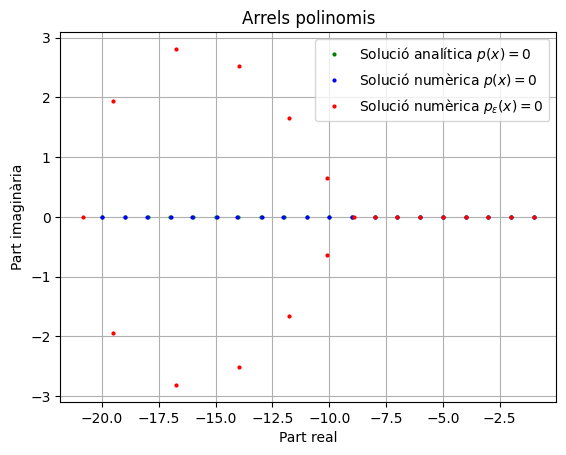

In [ ]:
import numpy as np
from numpy.polynomial import Polynomial
import matplotlib.pyplot as plt


# Creem el polinomi p(x) = (x+1)*(x+2)*...*(x+20)
P = Polynomial((1,1))
for i in range(2,21):
    P *=Polynomial((i,1))

# Arrels analítiques:
arrels = np.arange(-20,0)

# Arrels numèriques
arrels_numeriques = P.roots()

# Modifiquem molt poquet el coeficient a_19
P.coef[19]+=2**-23
arrels_error = P.roots()

print("Error numèric p(x)",np.max(np.abs(arrels-arrels_numeriques)))
print("Error numèric pe(x)",np.max(np.abs(arrels-arrels_error)))


#### Dibuixem les solucions obtingudes

# Creem la figura
fig, ax = plt.subplots()
ax.plot(arrels.real, arrels.imag, 'go', markersize=2)
ax.plot(arrels_numeriques.real, arrels_numeriques.imag, 'bo', markersize=2)
ax.plot(arrels_error.real, arrels_error.imag, 'ro', markersize=2)

# Títol
plt.title("Arrels polinomis")

# Eixos
plt.xlabel("Part real")
plt.ylabel("Part imaginària")

# Grid
plt.grid()

# Llegenda
plt.legend(['Solució analítica $p(x)=0$', 'Solució numèrica $p(x)=0$','Solució numèrica $p_\\varepsilon(x)=0$'])

# Mostrem el gràfic
plt.show()

&nbsp;

Així doncs, haurem de buscar estratègies més adients per calcular els valors propis.

&nbsp;

### **Determinació de VAPs i VEPs i Quocient de Rayleigh:**

Típicament, per tal de determinar els VAPs i VEPs d'una matriu primerament calcularem el VAPs i després els VEPS.

Així doncs, en aquest tema ens focalitzarem en diverses estratègies per fer-ho.

&nbsp;

Ara bé, si tenim un vector propi $\boldsymbol{v}$ és senzill calcular el seu valor propi $\lambda$ associat. Per fer-ho, introduïm prèviament la següent definició:

> #### **Definició:** quocient de Rayleigh
>
> Donat un vector $\boldsymbol{x}\in \mathbb{C}^n\setminus\{ \boldsymbol{0}\}$ i $A\in\mathcal{M}_n(\mathbb{C})$, definim el seu quocient de Rayleigh com:
>
>$$ \mathcal{R}(A,\boldsymbol{x}) = \frac{\boldsymbol{x}^* A\boldsymbol{x}}{\boldsymbol{x}^* \boldsymbol{x}}$$

⚠️ * vol dir transpost conjugat: fer la transposada i canviar el signe de la part imaginaria. Observem la observació següent:

&nbsp;

⚠️ **Observació:** Notem que, en el cas real $\boldsymbol{x}^*=\boldsymbol{x}^\top$.


&nbsp;

Basats en aquesta idea, notem que, donada la matriu $A$, si $\boldsymbol{v}$ és un vector propi de valor propi $\lambda$, tenim:

$$
 A\boldsymbol{v} = \lambda \boldsymbol{v}
$$

Així:

$$
    \frac{\boldsymbol{v}^* A\boldsymbol{v}}{\boldsymbol{v}^* \boldsymbol{v}} = \frac{\boldsymbol{v}^* \lambda\boldsymbol{v}}{\boldsymbol{v}^* \boldsymbol{v}} = \lambda\frac{\boldsymbol{v}^* \boldsymbol{v}}{\boldsymbol{v}^* \boldsymbol{v}} = \lambda
$$

I, per tant, donat un vector propi, podem determinar el seu valor propi fàcilment.

&nbsp;

#### *Exemple*

*Considerem la matriu $C$ donada per*

$$
C = \begin{pmatrix}1 & -3 & 3\\ -1 & 1 & 1 \\ -1 & -3 & 5\end{pmatrix}
$$

*de la qual sabem que té per vector propi*

$$
\boldsymbol{v} = \begin{pmatrix}0 \\ 1 \\ 1\end{pmatrix}
$$

*i volem determinar el seu valor propi $\lambda$ associat:*

$$
\begin{aligned}
\lambda &= \frac{\boldsymbol{v}^\top C\boldsymbol{v}}{\boldsymbol{v}^\top \boldsymbol{v}}
= \frac{\begin{pmatrix}0 & 1 & 1\end{pmatrix}\begin{pmatrix}1 & -3 & 3\\ -1 & 1 & 1 \\ -1 & -3 & 5\end{pmatrix}\begin{pmatrix}0 \\ 1 \\ 1\end{pmatrix}}{\begin{pmatrix}0 & 1 & 1\end{pmatrix}\begin{pmatrix}0 \\ 1 \\ 1\end{pmatrix}}\\
&= \frac{\begin{pmatrix}0 & 1 & 1\end{pmatrix}\begin{pmatrix}0 \\ 2 \\ 2\end{pmatrix}}{2}= \frac{4}{2} = 2
\end{aligned}        
$$

&nbsp;

## **Objectius particulars sobre VAPs:**

El que voldrem saber, a grans trets, és:

* **Localització Global dels VAPs** (Gerschgorin, vist a 3b)

* **Mètode de la potència: Càlcul del VAP de mòdul màxim i variacions del mètode**

* **Mètodes basats en transformacions de semblança** (Transformació de la matriu en una més senzilla que preservi el VAPs de manera que sigui més fàcil calcular-los)

&nbsp;

&nbsp;

## Localització Global dels valor propis

Recordem que al Tema 3 ja haviem vist el Teorema de Gerschgorin que ens permetia localitzar globalment els valors propis. Recordem ràpidament el resultat:

> ##### **Definició:** Discs de Gerschgorin
>
> Sigui $A\in\mathcal{M}_n(\mathbb{C})$ una matriu. Per cada fila $i=1,\ldots,n$ de la matriu considerem:
>
> $$R_i = \sum_{j\neq i} |a_{ij}|,$$
>
>i, definim els **discs de Gerschgorin per files** com
>
>$$ D_i = \{z\in\mathbb{C}\,\,|\,\,|z-a_{ii}| \leq R_i\} = \bar{D}(a_{ii},R_i),\qquad \forall i = 1,\ldots, n.$$
>
>&nbsp;
>
>De la mateixa manera, per cada columna $j=1,\ldots,n$ de la matriu, considerem:
>
>$$\mathcal{R}_j = \sum_{i\neq j} |a_{ij}|,$$
>
>i, definim els **discs de Gerschgorin per columnes** com
>
>$$\mathcal{D}_j = \{z\in\mathbb{C}\,\,|\,\,|z-a_{jj}| \leq \mathcal{R}_j\} = \bar{D}(a_{jj},\mathcal{R}_j),\qquad \forall j = 1,\ldots, n.$$

&nbsp;

> #### **Teorema de Gerschgorin**
>
> Els valors propis de la matriu $A$ es troben als discs per files de Gerschgorin, és a dir, per tot valor propi $\lambda$ de la matriu $A$, tenim que $\lambda\in D_i$ per algun $i=1,\ldots,n$.

> ##### **Corol·lari:**
>
> Els valors propis de la matriu $A$ es troben als discs per columnes de Gerschgorin, és a dir, per tot valor propi $\lambda$ de la matriu $A$, tenim que $\lambda\in \mathcal{D}_j$ per algun $j=1,\ldots,n$.

> ##### **Corol·lari 2:**
>
>Per tot valor propi $\lambda$ de $A$ és té
>$$\lambda \in \left(\bigcup_{i=1}^n D_i\right) \cap \left(\bigcup_{j=1}^n \mathcal{D}_j\right).$$

#### *Exemple:*

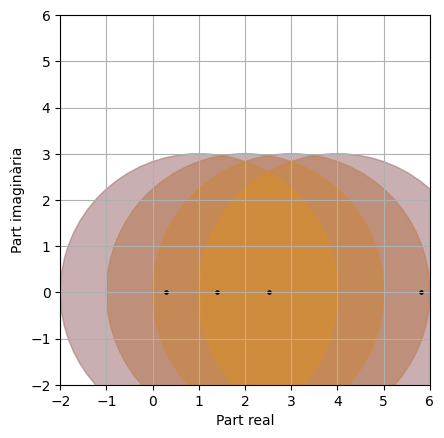

In [3]:
## Fem la intersecció entre la unió de discs per files i la unió de discs per columnes
#  per saber on estan localitzats els valors propis:
import numpy as np
import matplotlib.pyplot as plt

# Aquesta funció ens retorna els centres i radis dels discos
# de Gerschgorin per files.
def discsGerschgorin(A):
    # Obtenim dimensions de la matriu A:
    n, m = A.shape

    # Si la matriu no es quadrada retornem error:
    if n != m:
        raise Exception("Error! La matriu no és quadrada")

    # Calculem els centres:
    c = np.diag(A)

    # Calculem els radis:
    #r = np.sum(np.abs(A),axis=1) - np.abs(c)
    r = np.linalg.norm(A, axis =1, ord=1) - np.absolute(c)

    return c, r


## Procediment general:

# Matriu A "semi"-random:
dist1 = 1.5*(np.diag(np.random.rand(4)-0.5))
dist2 = 1.5*(np.diag(np.random.rand(4)-0.5))
# A = dist1 + (np.random.rand(4,4)-0.5)/3 + 1.j*((np.random.rand(4,4)-0.5)/3-dist2)

A = np.array([[1,1,1,1],
              [1,2,1,1],
              [1,1,3,1],
              [1,1,1,4]], dtype=np.float64)


# Calculem els vaps i els veps:
vaps, veps = np.linalg.eig(A)

# Disc de Gerschgorin per files i columnes
c,r = discsGerschgorin(A)
c2,r2 = discsGerschgorin(A.T)

# Centres i radis:
#print(c,r)

n = len(A)


## Dibuixem:
fig, ax = plt.subplots()

ax.set_aspect('equal')  # Fem l'escala dels eixos iguals
ax.grid(True) # Afegim el grid


# Anem dibuixant cada disc (per files):
for i in range(n):
    circle = plt.Circle((np.real(c[i]), np.imag(c[i])), r[i], color='blue', fill=True, alpha=0.3)
    ax.add_patch(circle)

# Anem dibuixant cada disc (per columnes):
for i in range(n):
    circle = plt.Circle((np.real(c2[i]), np.imag(c2[i])), r2[i], color='orange', fill=True, alpha=0.3)
    ax.add_patch(circle)

# Dibuixem els VAPS:
plt.scatter(np.real(vaps),np.imag(vaps),color="black", s=5)

# Limits dels eixos:
plt.xlim(-2, 6)
plt.ylim(-2, 6)

# Labels dels eixos:
plt.xlabel('Part real')
plt.ylabel('Part imaginària')

plt.show()

&nbsp;


> #### **Teorema de Gerschgorin (V2)**
>
> Cada component connexa de la unió de discs de Gerschgorin (per files o per columnes) conté tants VAPs com cercles hi ha en ella, on cercles i VAPs estan comptats amb la seva multiplicitat.

&nbsp;

&nbsp;

## Mètode de la potència

El mètode de la potència és, probablement, el mètode més senzill per calcular el VAP de mòdul màxim i el seu VEP associat.

Suposem $A\in\mathcal{M}_n(\mathbb{C})$ una matriu amb autovalors $\lambda_1, \lambda_2,\ldots,\lambda_n$ que suposarem ordenats de la forma

$$|\lambda_1| \geq |\lambda_2| \geq \ldots |\lambda_n|.$$

L'autovalor amb mòdul més gran es diu *dominant*, en cas de tenir $|\lambda_1| > |\lambda_2|$ direm que és *estrictament dominant*.

### **Mètode de la potència iterada amb quocient de Rayleigh**

El mètode es basa en la iteració següent:

$$
\left\{
\begin{aligned}&\boldsymbol{z}_0\in\mathbb{C}^n\setminus\{\boldsymbol{0}\},\\& \boldsymbol{z}_{k+1} = A\boldsymbol{z}_{k}, \,\,k\geq 0,\end{aligned}
\right.
$$

i en el càlcul dels termes successius $\{\sigma_k\}_{k\geq 0}$:

$$
\sigma_k = \frac{\boldsymbol{z}_k^*A\boldsymbol{z}_k}{\boldsymbol{z}_k^*\boldsymbol{z}_k} = \frac{\boldsymbol{z}_k^*\boldsymbol{z}_{k+1}}{\boldsymbol{z}_k^*\boldsymbol{z}_k},
$$

que tendiran a l'autovalor dominant $\lambda_1$.

&nbsp;

⚠️ **Observació:**  També es pot obtenir el valor de $\lambda_1$ dividint alguna de les component no nules de $\boldsymbol{z}_{k+1}$ i $\boldsymbol{z}_{k}$.

&nbsp;

&nbsp;

##### **Justificació del mètode**

Vegem-ho pel cas  de $A$ diagonalitzable, aleshores existeix una base de $\mathbb{C}^n$ formada pels $n$ VEPs de $A$, els quals són linealment independents: $\{\boldsymbol{v}_1,\boldsymbol{v}_2,\ldots,\boldsymbol{v}_n\}$. Així, tenim:

$$
\boldsymbol{z}_0 = \alpha_1\boldsymbol{v}_1 + \alpha_2\boldsymbol{v}_2 + \ldots + \alpha_n\boldsymbol{v}_n
$$

amb $\alpha_i\in\mathbb{C}, \forall i = 1,...,n$ i suposem $\alpha_1 \neq 0$. Per tant:

$$
\begin{array}{lll}\boldsymbol{z}_{k} &= A\boldsymbol{z}_{k-1} = A^2\boldsymbol{z}_{k-2} = \ldots = A^k\boldsymbol{z}_{0} & \quad (\text{iteracions del mètode})\\ & = A^k\left(\alpha_1\boldsymbol{v}_1 + \alpha_2\boldsymbol{v}_2 + \ldots + \alpha_n\boldsymbol{v}_n\right) & \quad(\text{definició de }\boldsymbol{z}_0)\\ & = \alpha_1A^k\boldsymbol{v}_1 + \alpha_2A^k\boldsymbol{v}_2 + \ldots + \alpha_nA^k\boldsymbol{v}_n & \quad(\text{operem})\\ & = \alpha_1\lambda_1^k\boldsymbol{v}_1 + \alpha_2\lambda_2^k\boldsymbol{v}_2 + \ldots + \alpha_n\lambda_n^k\boldsymbol{v}_n & \quad(A^k\boldsymbol{v}_i = \lambda_i^k\boldsymbol{v}_i)\\ & = \lambda_1^k\left(\alpha_1\boldsymbol{v}_1 + \alpha_2\cfrac{\lambda_2^k}{\lambda_1^k}\boldsymbol{v}_2 + \ldots + \alpha_n\cfrac{\lambda_n^k}{\lambda_1^k}\boldsymbol{v}_n\right)&\quad (\lambda_1^k \text{ factor comú}) \end{array}
$$

De la mateixa manera, tenim:

$$
\boldsymbol{z}_{k+1} = \lambda_1^{k+1}\left(\alpha_1\boldsymbol{v}_1 + \alpha_2\cfrac{\lambda_2^{k+1}}{\lambda_1^{k+1}}\boldsymbol{v}_2 + \ldots + \alpha_n\cfrac{\lambda_n^{k+1}}{\lambda_1^{k+1}}\boldsymbol{v}_n\right).
$$

Observem que com $|\lambda_1| > |\lambda_i|$, $\forall i = 2,\ldots,n$ tenim:

$$
\left\{
\begin{aligned}
&\boldsymbol{z}_{k} = \lambda_1^k\left[\alpha_1\boldsymbol{v}_1 + \mathcal{O}\left(\cfrac{|\lambda_2|^k}{|\lambda_1|^k}\right)\right],\\
&\boldsymbol{z}_{k}^* = \overline{\lambda}_1^k\left[\overline{\alpha}_1\boldsymbol{v}_1^* + \mathcal{O}\left(\cfrac{|\lambda_2|^k}{|\lambda_1|^k}\right)\right].
\end{aligned}
\right.
$$

D'aquesta forma:

$$
\begin{aligned}
\sigma_k &= \frac{\boldsymbol{z}_k^*\boldsymbol{z}_{k+1}}{\boldsymbol{z}_k^*\boldsymbol{z}_k}\\ & = \frac{\overline{\lambda}_1^k\left[\overline{\alpha}_1\boldsymbol{v}_1^* + \mathcal{O}\left(\cfrac{|\lambda_2|^k}{|\lambda_1|^k}\right)\right]\lambda_1^{k+1}\left[\alpha_1\boldsymbol{v}_1 + \mathcal{O}\left(\cfrac{|\lambda_2|^{k+1}}{|\lambda_1|^{k+1}}\right)\right]}{\overline{\lambda}_1^k\left[\overline{\alpha}_1\boldsymbol{v}_1^* + \mathcal{O}\left(\cfrac{|\lambda_2|^k}{|\lambda_1|^k}\right)\right]\lambda_1^k\left[\alpha_1\boldsymbol{v}_1 + \mathcal{O}\left(\cfrac{|\lambda_2|^k}{|\lambda_1|^k}\right)\right]}\\
& = \frac{\lambda_1^{k+1}\overline{\lambda}_1^k\alpha_1\overline{\alpha}_1\boldsymbol{v}_1^*\boldsymbol{v}_1
\left[1 + \mathcal{O}\left(\cfrac{|\lambda_2|^k}{|\lambda_1|^k}\right)\right]}{\lambda_1^{k}\overline{\lambda}_1^k\alpha_1\overline{\alpha}_1\boldsymbol{v}_1^*\boldsymbol{v}_1
\left[1 + \mathcal{O}\left(\cfrac{|\lambda_2|^k}{|\lambda_1|^k}\right)\right]}\\
& = \frac{\lambda_1
\left[1 + \mathcal{O}\left(\cfrac{|\lambda_2|^k}{|\lambda_1|^k}\right)\right]}{1 + \mathcal{O}\left(\cfrac{|\lambda_2|^k}{|\lambda_1|^k}\right)} \xrightarrow[\,\,k \longrightarrow +\infty\,\,]{}\lambda_1\\
\end{aligned}
$$


&nbsp;





##### **Teorema**

Sigui $A$ diagonalitzable amb autovalors $\lambda_1,\lambda_2,\ldots,\lambda_n$ tals que existeix un $r\in\{1,2,\ldots,n\}$ tals que

*   $|\lambda_1| = |\lambda_2| = \ldots = |\lambda_r| > |\lambda_{r+1}| \geq |\lambda_{r+2}| \geq \ldots \geq |\lambda_n|$,

*   $\lambda_1 = \lambda_2 = \ldots = \lambda_r$.

Aleshores, per tot $\boldsymbol{z}_0 = \alpha_1\boldsymbol{v}_1 + \alpha_2\boldsymbol{v}_2 + \ldots + \alpha_n\boldsymbol{v}_n$, amb $(\alpha_1,\ldots,\alpha_r)\in\mathbb{C}^r\setminus\{\boldsymbol{\boldsymbol{0}}\}$ es té:

1. $\displaystyle{\lim_{k\to +\infty} \sigma_k = \lim_{k\to +\infty} \frac{\boldsymbol{z}_k^*\boldsymbol{z}_{k+1}}{\boldsymbol{z}_k^*\boldsymbol{z}_k} = \lambda_1}$

2. $\displaystyle{\lim_{k\to +\infty} \frac{1}{\lambda_1^k}\boldsymbol{z}_k = \boldsymbol{v}}$

on $\boldsymbol{v}$ és un vector propi associat a $\lambda_1$.

&nbsp;

##### **Corol·lari**

En les mateixes hipòtesis del Teorema anterior, si $\boldsymbol{z}_0$ és tal que per algun $j\in\{r+1,r+2,\ldots,n\}$ es té:

* $\alpha_1 = \alpha_2 = \ldots = \alpha_{j-1} = 0, \quad \alpha_j \neq 0$

* $|\lambda_j| > |\lambda_{j+1}|$

Aleshores:

1. $\displaystyle{\lim_{k\to +\infty} \sigma_k = \lim_{k\to +\infty} \frac{\boldsymbol{z}_k^*\boldsymbol{z}_{k+1}}{\boldsymbol{z}_k^*\boldsymbol{z}_k} = \lambda_j}$

2. $\displaystyle{\lim_{k\to +\infty} \frac{1}{\lambda_j^k}\boldsymbol{z}_k = \boldsymbol{v}}$

on $\boldsymbol{v}$ és un vector propi associat a $\lambda_j$.

&nbsp;

&nbsp;

### **Mètode de la potència iterada amb quocient de Rayleigh normalitzat**

El mètode es basa en la iteració següent:

$$
\left\{
\begin{aligned}&\boldsymbol{z}_0\in\mathbb{C}^n\setminus\{\boldsymbol{0}\},\\& \boldsymbol{z}_{k+1} = \cfrac{A\boldsymbol{z}_{k}}{\|A\boldsymbol{z}_{k}\|}, \,\,k\geq 0,\end{aligned}
\right.
$$

i en el càlcul dels termes successius $\{\sigma_k\}_{k\geq 0}$:

$$
\sigma_k = \boldsymbol{z}_k^*A\boldsymbol{z}_k,
$$

que tendiran a l'autovalor dominant $\lambda_1$.

&nbsp;

⚠️ **Observació 1:** Amb aquesta variant del mètode evitem que els valors de $\boldsymbol{z}_k$ es disparin (si $|\lambda_1| > 1$) o prenguin valors molt petits (si $|\lambda_1| < 1$).

&nbsp;

⚠️ **Observació 2:** Els resultats del punt 1 del teorema i el corol·lari anterior anterior apliquen al mètode, pel punt 2 no és necessari fer la normalització per $\lambda_i^k$.

&nbsp;

#### *Exemple:*



Considerem la matriu

$$
A = \begin{pmatrix}1 & -3 & 3\\ -1 & 1 & 1 \\ -1 & -3 & 5\end{pmatrix}
$$

i el vector inicial

$$
    \boldsymbol{z}_0 = \begin{pmatrix}-1\\\,0\\\,0\end{pmatrix}
$$

i volem calcular el seu VAP dominant i el seu VEP associat.

&nbsp;

Si iterem, obtenim:

&nbsp;



| Iteració ($k$) |                                                        $\boldsymbol{z}_k$ |
|----------------|---------------------------------------------------------------------------|
|              1 | (-5.7735026918962584e-01, 5.7735026918962584e-01, 5.7735026918962584e-01) |
|              2 | (-2.2941573387056172e-01, 6.8824720161168529e-01, 6.8824720161168518e-01) |
|              3 | (-1.0050378152592135e-01, 7.0352647068144858e-01, 7.0352647068144847e-01) |
|       $\vdots$ |                                                                 $\vdots$  |
|             20 | (-6.7434611821184786e-07, 7.0710678118433601e-01, 7.0710678118843751e-01) |
|       $\vdots$ |                                                                 $\vdots$  |
|             50 | ( 4.3901393283843279e-03, 7.0490149022526716e-01, 7.0929162955365188e-01) |
|       $\vdots$ |                                                                 $\vdots$  |
|            100 | ( 7.0710678118649717e-01, 1.0089151736281831e-13, 7.0710678118659798e-01) |
|            101 | ( 7.0710678118652226e-01, 5.0431880893599534e-14, 7.0710678118657277e-01) |
|            102 | ( 7.0710678118653492e-01, 2.5229818234607130e-14, 7.0710678118656012e-01) |
|            103 | ( 7.0710678118654113e-01, 1.2601031329495640e-14, 7.0710678118655390e-01) |
|            104 | ( 7.0710678118654435e-01, 6.3560268159790488e-15, 7.0710678118655079e-01) |
|            105 | ( 7.0710678118654591e-01, 3.1918911957973318e-15, 7.0710678118654902e-01) |
|       $\vdots$ |                                                                 $\vdots$  |
| $\infty$ | $(\sqrt{2}/2,\,0,\,\sqrt{2}/2)$

&nbsp;

I podem calcular el seu valor propi associat:

$$
\lambda = \begin{pmatrix}\sqrt{2}/2 & 0 & \sqrt{2}/2\end{pmatrix}\begin{pmatrix}1 & -3 & 3\\ -1 & 1 & 1 \\ -1 & -3 & 5\end{pmatrix}\begin{pmatrix}\sqrt{2}/2 \\ 0 \\ \sqrt{2}/2\end{pmatrix} = \begin{pmatrix}\sqrt{2}/2 & 0 & \sqrt{2}/2\end{pmatrix}\begin{pmatrix}2\sqrt{2} \\ 0 \\ 2\sqrt{2}\end{pmatrix} = 4
$$

#### *Exercici 3*

*Apliqueu el mètode de la potència (amb quocient de components) a la matriu $\begin{pmatrix}0 & 1\\ -1 & 0\end{pmatrix}$ amb $\boldsymbol{z}^{(0)} = \begin{pmatrix}1 & 1\end{pmatrix}^\top$. Per què divergeix?*


##### Resolució

Utilitzem el mètode de la potència iterada:

* $\boldsymbol{z}^{(1)} = \displaystyle{A\boldsymbol{z}^{(0)}= \begin{pmatrix}0 & 1\\ -1 & 0\end{pmatrix}\begin{pmatrix}1 \\ 1\end{pmatrix} = \begin{pmatrix}-1 \\ 1\end{pmatrix}}$

&nbsp;

* $\boldsymbol{z}^{(2)} = \displaystyle{A\boldsymbol{z}^{(1)}= \begin{pmatrix}0 & 1\\ -1 & 0\end{pmatrix}\begin{pmatrix}-1 \\ 1\end{pmatrix} = \begin{pmatrix} 1 \\ 1\end{pmatrix}}$

&nbsp;

Fixem-nos que $\boldsymbol{z}^{(2)} = \boldsymbol{z}^{(0)}$ i per tant el mètode és divergent.

&nbsp;

Fixem-nos que en aquest cas podem calcular els valors pròpis fàcilment amb el polinomi característic:

$$
p(\lambda) = \det(A-\lambda Id) = \det\begin{pmatrix}-\lambda & 1\\ -1 & -\lambda\end{pmatrix} = \lambda^2+1 = (\lambda + i)(\lambda -i)
$$

Així doncs els VAPs són $\pm i$ i per tant $|i| = |-i| = 1$. Així doncs tenim dos valors pròpis diferents dominants i, en conseqüència, el mètode no convergirà.

&nbsp;

#### **Remarques importants del mètode de la potència:**


*   La velocitat de convergència del mètode depèn del quocient $\frac{|\lambda_2|}{|\lambda_1|}$. Com més petit, més ràpid convergirà el mètode.



* Pel cas de matriu a coeficients reals, si $|\lambda_1| > |\lambda_2|$, necessàriament $\lambda_1$ ha de ser un valor real.

&nbsp;

#### *Exercici*

*Programeu el mètode de la potència iterada amb quocient de Rayleigh normalitzat que, donat una matriu $A$ i un vector inicial $\boldsymbol{z}_0$ calculi el valor propi dominant i el seu vector propi associat.*

*Utilitzeu els dos paràmetres opcionals següents:*

* *`tol=1.e-10`, que ens indiqui la tolerància mínima amb la que volem la solució: $|\sigma_{k}-\sigma_{k-1}| < \varepsilon$. Un cop assolida, el mètode ha de retornar la solució.*

* *`maxIter=100`, que controli el nombre màxim d'iteracions possibles.*

*La funció ha de retornar el VAP `l`, el seu VEP `v` associat i el nombre d'iteracions realitzades. Si no s'ha assolit la tolerància en el nombre màxim d'iteracions el valor del nombre d'iteracions realitzades s'ha de retornar amb signe negatiu.*

In [ ]:
## Espai per fer l'exercici:
import numpy as np

def potIter(A, z0, tol=1.e-10, maxIter=100):

    z = z0.copy()
    sigma0 = z0.T@A@z0

    for i in range(maxIter):
        Az0 = A@z0
        z = Az0 / np.linalg.norm(Az0)

        sigma = z.T@A@z

        if (np.abs(sigma - sigma0) < tol):
            return z, sigma, i + 1

        z0 = z.copy()
        sigma0 = sigma

    return z, sigma, -(i + 1)

A = np.array([[1, -3, 3],
              [-1, 1, 1],
              [-1,-3, 5]], dtype=np.float64)

xold = np.array([-1, 0, 0], dtype=np.float64)

v, l, i = potIter(A, xold)

print(f"v es: {v}")
print(f"l es {l}")
print(f" i es: {i}")



v es: [-7.07106781e-01  3.61645158e-11 -7.07106781e-01]
l es 4.000000000051144
 i es: 88


## Variants del mètode de la potència

En veurem tres:

* Mètode de la potència inversa

* Mètode de la potència desplaçada

* Mètode de la potència inversa desplaçada

&nbsp;

## Mètode de la potència inversa

Recordem que si $\lambda \neq 0$ és VAP de la matriu $A$ de VEP $\boldsymbol{v}$ aleshores, si aquesta té inversa:

$$
A\boldsymbol{v} = \lambda\boldsymbol{v} \Longleftrightarrow A^{-1}\boldsymbol{v}  = \frac{1}{\lambda}\boldsymbol{v}
$$

és a dir $\cfrac{1}{\lambda}$ és VAP d'$A^{-1}$ de vep $\boldsymbol{v}$.

Així, només cal aplicar el mètode de la potència amb la matriu $A^{-1}$ per tal d'obtenir el VAP de |A| de mòdul mínim (aplicant les mateixes condicions vistes pel Teorema i Corol·lari anterior).

Ara bé, enlloc de calcular la inversa, i considerar la iteració

$$
    \boldsymbol{z}_{k+1} = A^{-1}\boldsymbol{z}_k
$$

podem fer la descomposició de $A$ i resoldre el sistema lineal:

$$
    A\boldsymbol{z}_{k+1} = \boldsymbol{z}_{k}
$$

#### *Exercici:*

*Programeu el mètode de la potència iterada inversaamb quocient de Rayleigh normalitzat que, donat una matriu $A$ i un vector inicial $\boldsymbol{z}_0$ calculi el valor propi de menor mòdul i el seu vector propi associat.*

*Utilitzeu els dos paràmetres opcionals següents:*

* *`tol=1.e-10`, que ens indiqui la tolerància mínima amb la que volem la solució: $|\sigma_{k}-\sigma_{k-1}| < \varepsilon$. Un cop assolida, el mètode ha de retornar la solució.*

* *`maxIter=100`, que controli el nombre màxim d'iteracions possibles.*

*La funció ha de retornar el VAP `l` més petita en mòdul, el seu VEP `v` associat i el nombre d'iteracions realitzades. Si no s'ha assolit la tolerància en el nombre màxim d'iteracions el valor del nombre d'iteracions realitzades s'ha de retornar amb signe negatiu. Feu-ho sense fer el càlcul de la matriu inversa.*

In [1]:
## Espai per fer l'exercici
import numpy as np
from scipy.linalg import solve_triangular
from scipy.linalg import lu_factor

# Funció per recuperar el vector de permutacions
def pivot_to_permutation(piv):
    perm = np.arange(len(piv))
    for i in range(len(piv)):
        perm[i], perm[piv[i]] = perm[piv[i]], perm[i]
    return perm 


def potInv(A, z0, tol=1.e-10, maxIter=10000):

    # Definim les matrius per resoldre el sistema
    M, piv = lu_factor(A)
    p = pivot_to_permutation(piv)
    print(f"pivot {piv}")
    U = np.triu(M)
    L = np.tril(M, -1) + np.eye(len(M))

    z = z0.copy()
    sigma0 = z0.T@A@z0
    y = z0 / np.linalg.norm(z0)

    for i in range(maxIter):  

        sol1 = solve_triangular(L, y[p[:]], lower=True)
        z = solve_triangular(U, sol1)

        # Normalitzem el vector
        y = z / np.linalg.norm(z)

        # Mirem si hem assolit la precisió desitjada
        sigma = y.T@A@y

        if (np.abs(sigma - sigma0) < tol):
            return y, sigma, i + 1

        sigma0 = sigma.copy()

    return z, sigma, -(i + 1)

    
A = np.array([[3,2,1,1,1,2,1,1,1,2],
              [2,6,4,1,3,4,4,4,0,2],
              [1,4,6,3,3,4,3,3,0,2],
              [1,1,3,4,2,4,2,1,1,2],
              [1,3,3,2,6,4,4,3,2,3],
              [2,4,4,4,4,7,4,4,1,4],
              [1,4,3,2,4,4,6,3,1,2],
              [1,4,3,1,3,4,3,5,0,2],
              [1,0,0,1,2,1,1,0,2,1],
              [2,2,2,2,3,4,2,2,1,4]],dtype=np.float64)

x = np.array([1,0,0,0,0,0,0,0,0,0], dtype=np.float64)

B = np.array([[1, -3, 3],
              [-1, 1, 1],
              [-1,-3, 5]], dtype=np.float64)

xold = np.array([-1, 0, 0], dtype=np.float64)
 
v1, l1, i1 = potInv(A, x)
v2, l2, i2 = potInv(B, xold)
# l, v = eigs(B,k=1,which='SM',tol=1.e-10)


print(f"v es: {v2}")
print(f"i {i2}")
#print(f"l es {l}")

print(f"v2 {l2}")




pivot [0 1 2 5 4 5 6 7 8 9]
pivot [0 2 2]
v es: [-0.57735027 -0.57735027 -0.57735027]
i 33
v2 0.9999999999223902


#### **Exercici:**

Trobeu el valor valor propi amb mòdul més petit de la matriu
$$
A = \begin{pmatrix}1 & -3 & 3\\ -1 & 1 & 1 \\ -1 & -3 & 5\end{pmatrix}
$$

partint del vector

$$
    \boldsymbol{z}_0 = \begin{pmatrix}-1\\\,0\\\,0\end{pmatrix}
$$

In [6]:
# Faig el qüestionari
from scipy.sparse.linalg import eigs

A = np.array([[3,2,1,1,1,2,1,1,1,2],
              [2,6,4,1,3,4,4,4,0,2],
              [1,4,6,3,3,4,3,3,0,2],
              [1,1,3,4,2,4,2,1,1,2],
              [1,3,3,2,6,4,4,3,2,3],
              [2,4,4,4,4,7,4,4,1,4],
              [1,4,3,2,4,4,6,3,1,2],
              [1,4,3,1,3,4,3,5,0,2],
              [1,0,0,1,2,1,1,0,2,1],
              [2,2,2,2,3,4,2,2,1,4]],dtype=np.float64)

x = np.array([1,0,0,0,0,0,0,0,0,0], dtype=np.float64)

v1, l1, i1 = potIter(A, x)
v2, l2, i2 = potInv(A, x)
l, v = eigs(A,k=1,which='SM',tol=1.e-10)


print(f" mi l1 {l1}")
print(f" mi l2 {l2}")
print(l)

pivot [0 1 2 5 4 5 6 7 8 9]
 mi l1 28.123433577802665
 mi l2 0.07782852712600347
[0.07782853+0.j]
